## Temparature scaling calibration

### Imports

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from datasets import load_dataset
from tqdm import tqdm
from typing import Optional

sys.path.append("../../../services/")
from index import Index, IndexDataset
from process_funcs import retrieve_answer_token_index
from metric_funcs import calculate_ece_adaptive_bins

/workspace/Diplom/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Preparation

In [2]:
HPARAMETER_SEARCH_TRIALS = 15

torch.random.manual_seed(42)

In [3]:
for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"Index {i}: {props.name}, UUID: {props.uuid}")

Index 0: NVIDIA L40, UUID: 441e6008-cd27-34b5-c81a-17dad9d4a894
Index 1: NVIDIA L40S, UUID: c15d4e7a-29b2-896a-f7bf-3d1a528040a5
Index 2: NVIDIA L40, UUID: 31a471eb-a3b0-032b-8b74-9bd805c42af3
Index 3: NVIDIA L40, UUID: 7b7e27a5-a434-d736-eabd-b9414645af76
Index 4: NVIDIA L40S, UUID: d5913034-d8e8-b46e-940e-7df6d85d3884
Index 5: NVIDIA H100 NVL, UUID: d4d3fa02-fdea-80f5-9082-0157b1423027
Index 6: NVIDIA H100 PCIe, UUID: 1ea36751-5cc4-4522-aa5e-55350c485c0c


In [4]:
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print(device)

cuda:3


In [5]:
index = Index("../../../index_data/mistral0.3_RACE_attn_cropped_12000")

## Core functions

In [6]:
# Module which will learn temperature value

class TemperatureCalibration(nn.Module):
    def __init__(self, device=device):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1, device=device))

    def forward(self, logits):
        return torch.div(logits, self.temperature)

    def calibrate(self, logits):
        self.eval()
        with torch.no_grad():
            return self.forward(logits)

In [7]:
# Function to fit the calibration model

def fit_calibration_model(
    model: nn.Module,
    train_data: IndexDataset,
    test_data: Optional[IndexDataset] = None,
    lr_max=1e-2,
    lr_min=1e-4,
    batch_size=64,
    epochs=3,
    plot_interval=3,
    verbose=True
):
    optimizer = torch.optim.Adam(model.parameters(), lr_max)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, epochs, lr_min
    )

    train_losses = []
    test_losses = []
    iterations = []

    iteration_counter = 0

    for _ in range(epochs):
        for start in range(0, len(train_data) - batch_size, batch_size):
            batch_data = train_data.get(start, start + batch_size)
            if not batch_data:
                continue

            optimizer.zero_grad()
            batch_confidence_scores = batch_data[f"scores"].to(device)
            batch_labels = batch_data["targets"]
            train_cal_scores = model(batch_confidence_scores)

            train_loss = torch.nn.functional.cross_entropy(
                train_cal_scores,
                batch_labels
            )

            train_loss.backward()
            # torch.nn.utils.clip_grad_norm_(temp_model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            if (
                test_data is not None
                and iteration_counter % plot_interval == 0
            ):
                train_loss = train_loss.item()
                train_losses.append(train_loss)

                test_batch = test_data.get(0, min(batch_size, len(test_data)))
                if test_batch:
                    test_confidence_scores = test_batch[f"scores"].to(device)
                    test_labels = test_batch["targets"]
                    
                    with torch.no_grad():
                        test_cal_scores = model(test_confidence_scores)
                        test_loss = torch.nn.functional.cross_entropy(
                            test_cal_scores,
                            test_labels
                        )
                        test_losses.append(test_loss.item())
                    
                    iterations.append(iteration_counter)
            iteration_counter += 1

    if len(iterations) > 0 and verbose:
        plt.figure(figsize=(4, 4))
        plt.plot(iterations, train_losses, label="Train Loss", marker="o")
        if len(test_losses) > 0:
            plt.plot(iterations, test_losses, label="Test Loss", marker="s")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title("Training and Test Loss over Iterations")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return model

In [8]:
# Function to find the best hyperparameters for calibration model

def fit_hparameters(
    train_data: IndexDataset,
    test_data: IndexDataset,
    verbose=False
    ):
    results = []
    for _ in tqdm(range(HPARAMETER_SEARCH_TRIALS)):
        lr_max = np.random.choice([1e-2, 5e-3, 1e-3, 5e-4, 1e-4])
        lr_min = np.random.choice([1e-3, 1e-4, 5e-5, 1e-5, 5e-6, 1e-6])
        batch_size = 16
        epochs = np.random.choice([3, 5, 10])

        model = fit_calibration_model(
            TemperatureCalibration(),
            train_data=train_data,
            test_data=test_data,
            lr_max=lr_max,
            lr_min=lr_min,
            batch_size=batch_size,
            epochs=epochs,
            verbose=verbose
        )
        
        val_calibrated_probs = torch.softmax(
            model.calibrate(test_data.get()["scores"]),
            dim=-1
        ).gather(1, test_data.get()["tok_ids"].unsqueeze(0)).squeeze(0)
        ece = calculate_ece_adaptive_bins(
            val_calibrated_probs,
            test_data.get()["labels"],
            verbose=verbose,
            device=device 
        )
        
        print(f"Current ECE: {ece}")
        results.append(
            {
                "hparameters": {
                    "lr_max": lr_max,
                    "lr_min": lr_min,
                    "batch_size": batch_size,
                    "epochs": epochs,
                },
                "parameters": model.state_dict(),
                "ece": ece,
            }
        )

    return min(results, key=lambda x: x["ece"])

In [9]:
# Function to test calibration model

def test_calibration_model(
    X_test: torch.Tensor,
    X_cal_test: torch.Tensor,
    y_test: torch.Tensor
):
    not_calibrated_test_answers_probs = X_test
    calibrated_test_answers_probs = X_cal_test
    
    print(
        f"ECE on NON calibrated answer (test data): {
            calculate_ece_adaptive_bins(
                not_calibrated_test_answers_probs,
                y_test,
                verbose=True,
                device=device
            )
        }"
    )

    print(
        f"ECE on calibrated answer (test data): {
            calculate_ece_adaptive_bins(
                calibrated_test_answers_probs,
                y_test,
                verbose=True,
                device=device
            )
        }"
    )
    
    accuracies = (
        y_test
    ).to(torch.float)
    print(f"Accuracy on answer from test: {torch.mean(accuracies).item()}")

## Dataset and Index preparation

In [10]:
dataset = load_dataset("ehovy/race", "high", split="train").select(range(12000))
index = Index("../../index_data/qwen2.5-7B_RACE_attn_cropped_12000")

## Temperature calibration

### Data preparing

In [11]:
# Function to process data before retrieving
def process_elements(elems: np.array):
    processed = {}

    targets = torch.zeros(len(elems), device=device, dtype=torch.long)
    labels = torch.zeros(len(elems), device=device, dtype=torch.long)
    tok_ids = torch.zeros(len(elems), device=device, dtype=torch.long)
    for i, elem in enumerate(elems):
        answer_token_index = retrieve_answer_token_index(elem["score_data"])
        targets[i] = torch.tensor(
            elem["score_data"][answer_token_index]["top_tokens"]
                .index(str(ord(elem["dataset_elem"]["answer"]) - ord('A')))
        )
        labels[i] = (elem["score_data"][answer_token_index]["token"] == str(ord(elem["dataset_elem"]["answer"]) - ord('A')))
        tok_ids[i] = torch.tensor(
            elem["score_data"][answer_token_index]["top_tokens"]
                .index(elem["score_data"][answer_token_index]["token"])
        )

    processed["targets"] = targets
    processed["labels"] = labels
    processed["tok_ids"] = tok_ids

 
    final_token_scores = torch.stack(
        [
            x
            ["score_data"]
            [retrieve_answer_token_index(x["score_data"])]
            ["top_logits"] 
            for x in elems
        ]
    ).clamp(-100).to(dtype=torch.float32, device=device)
    
    processed[f"scores"] = final_token_scores

    return processed

In [12]:
train = IndexDataset(
    index, process_elements, split="train", load_all_data=True
)
val = IndexDataset(
    index, process_elements, split="val", load_all_data=True
)
test = IndexDataset(
    index, process_elements, split="test", load_all_data=True
)

IndexError: list index out of range

### Training model and finding best hparameters

  0%|          | 0/15 [00:00<?, ?it/s]

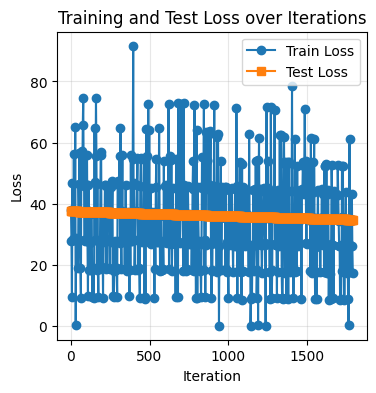

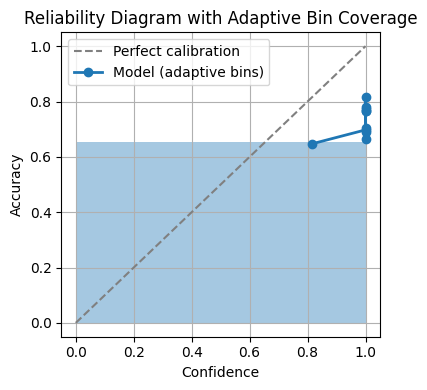

  7%|▋         | 1/15 [00:02<00:36,  2.63s/it]

Current ECE: 0.25104251503944397


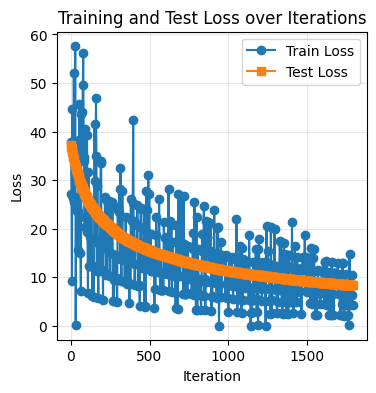

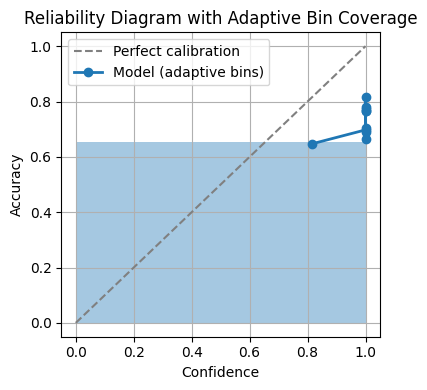

 13%|█▎        | 2/15 [00:05<00:34,  2.65s/it]

Current ECE: 0.25104251503944397


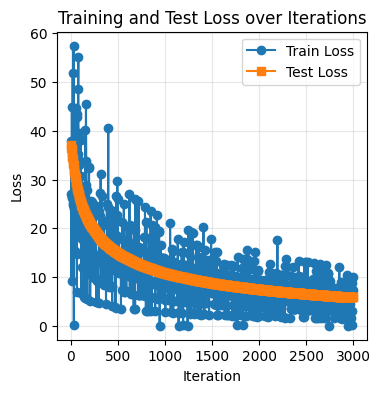

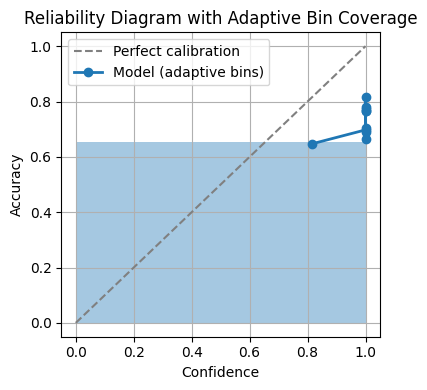

 20%|██        | 3/15 [00:09<00:38,  3.20s/it]

Current ECE: 0.25104251503944397


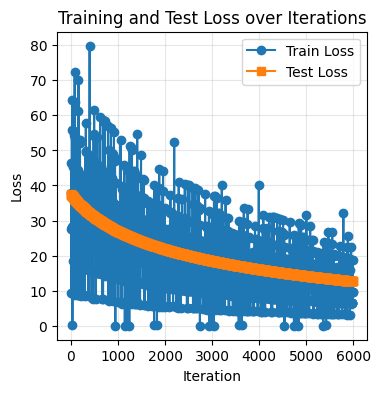

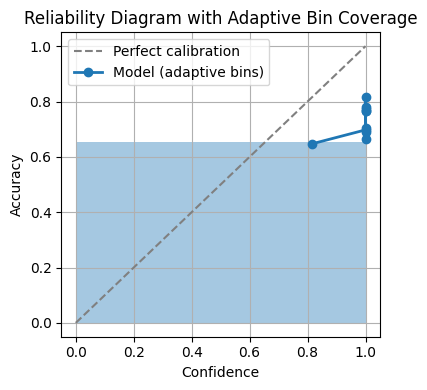

 27%|██▋       | 4/15 [00:17<00:57,  5.19s/it]

Current ECE: 0.25104251503944397


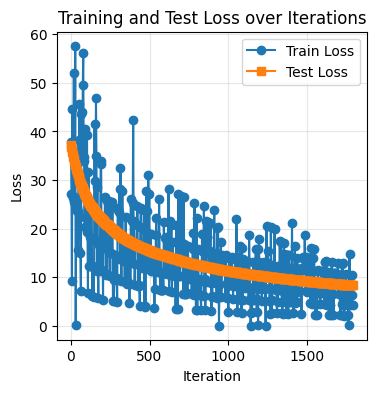

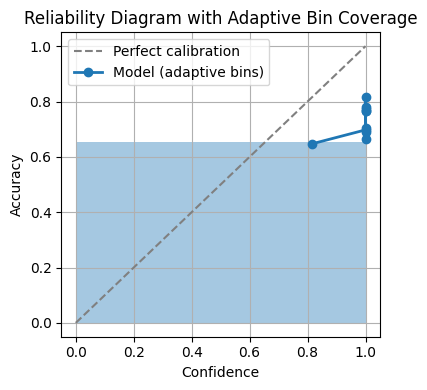

 33%|███▎      | 5/15 [00:20<00:42,  4.30s/it]

Current ECE: 0.25104251503944397


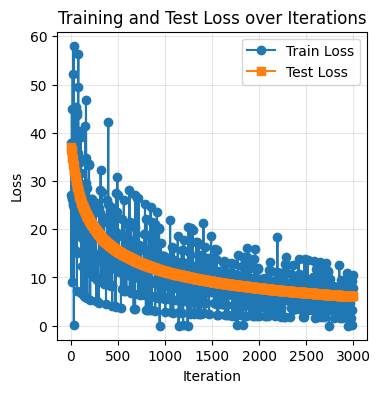

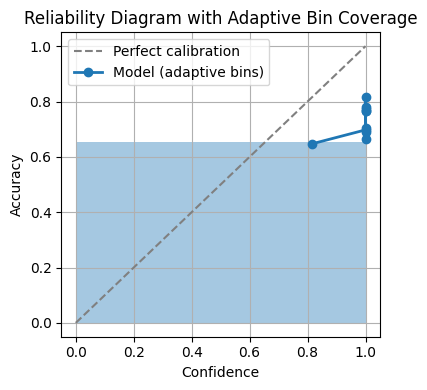

 40%|████      | 6/15 [00:24<00:38,  4.32s/it]

Current ECE: 0.25104251503944397


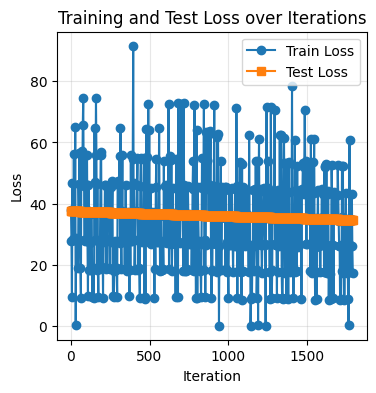

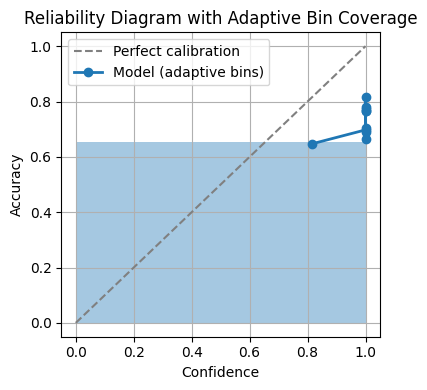

 47%|████▋     | 7/15 [00:27<00:29,  3.75s/it]

Current ECE: 0.25104251503944397


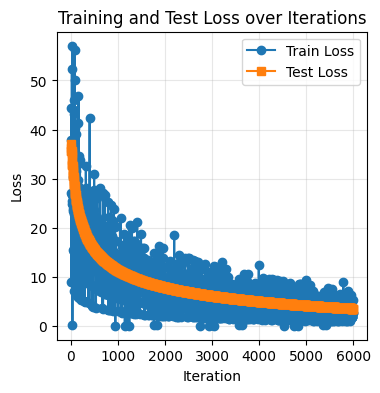

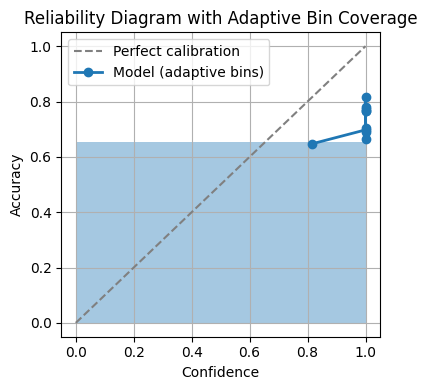

 53%|█████▎    | 8/15 [00:34<00:35,  5.06s/it]

Current ECE: 0.25102484226226807


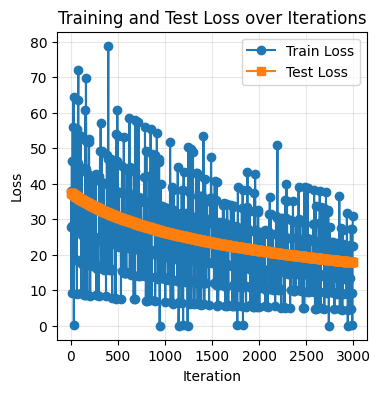

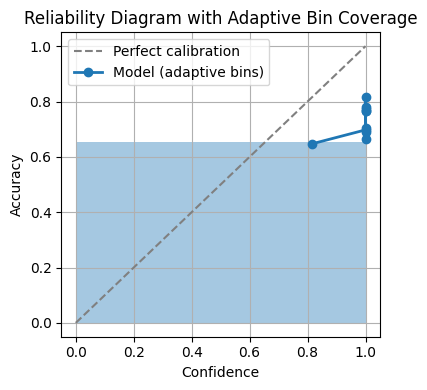

 60%|██████    | 9/15 [00:39<00:28,  4.83s/it]

Current ECE: 0.25104251503944397


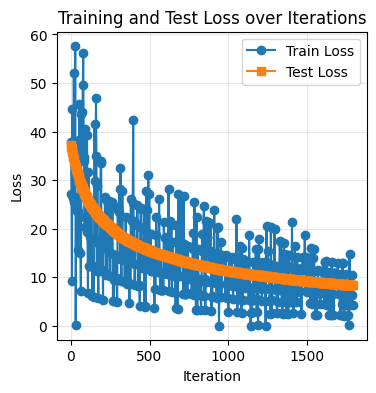

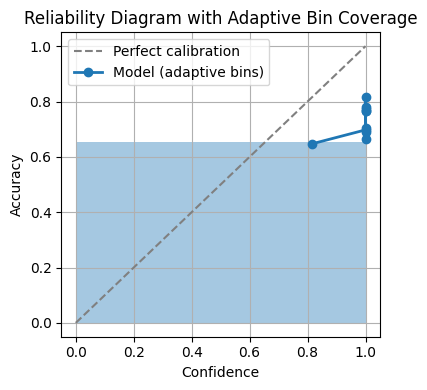

 67%|██████▋   | 10/15 [00:42<00:21,  4.21s/it]

Current ECE: 0.25104251503944397


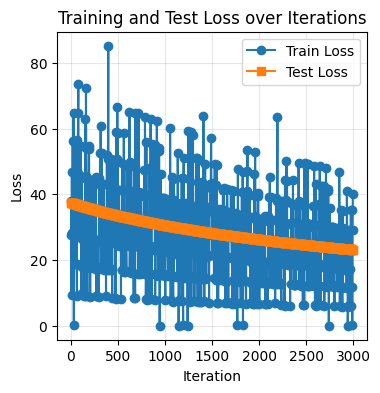

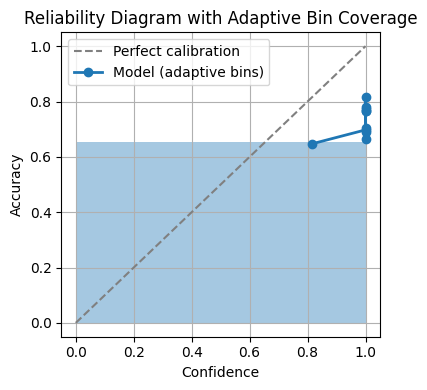

 73%|███████▎  | 11/15 [00:46<00:16,  4.19s/it]

Current ECE: 0.25104251503944397


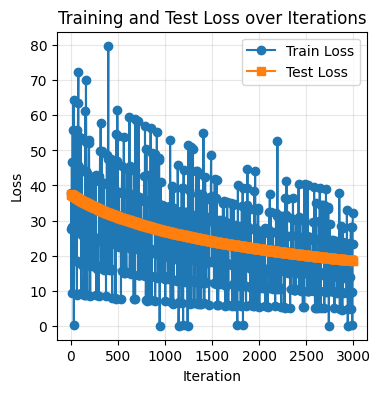

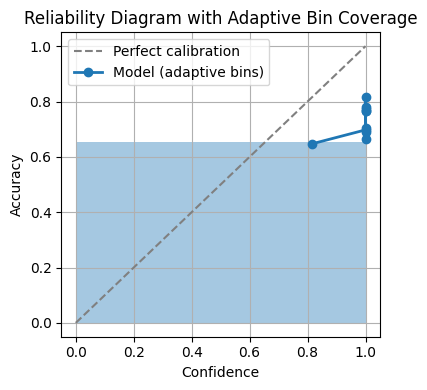

 80%|████████  | 12/15 [00:50<00:12,  4.24s/it]

Current ECE: 0.25104251503944397


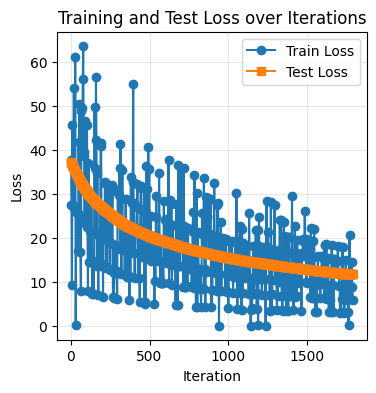

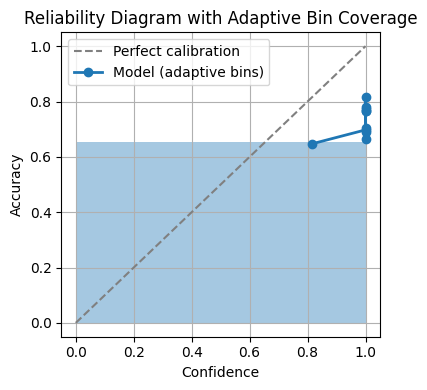

 87%|████████▋ | 13/15 [00:53<00:07,  3.82s/it]

Current ECE: 0.25104251503944397


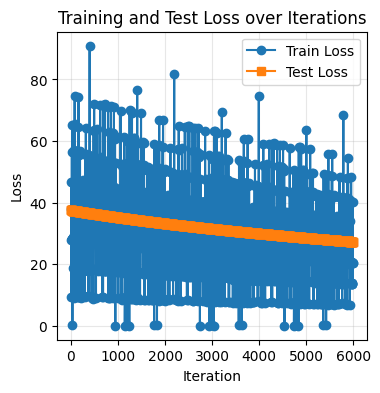

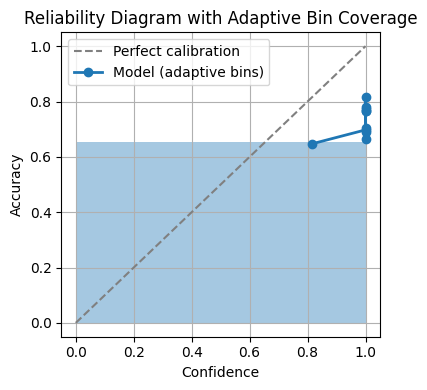

 93%|█████████▎| 14/15 [01:01<00:05,  5.18s/it]

Current ECE: 0.25104251503944397


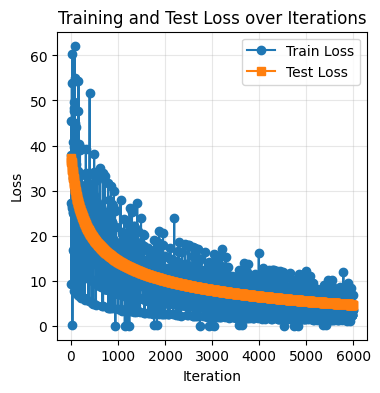

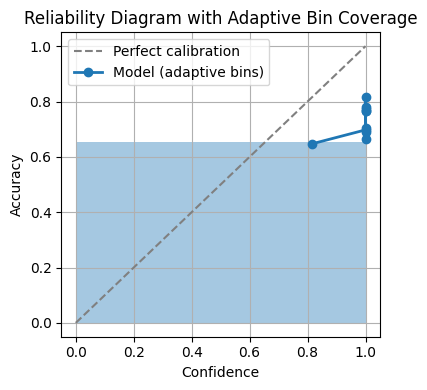

100%|██████████| 15/15 [01:08<00:00,  4.58s/it]

Current ECE: 0.2510424554347992


In [ ]:
fit_results = fit_hparameters(
    train_data=train,
    test_data=val,
    verbose=True
)

### Testing model

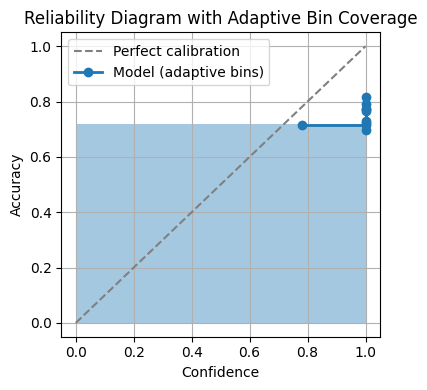

ECE on NON calibrated answer (test data): 0.22852376103401184


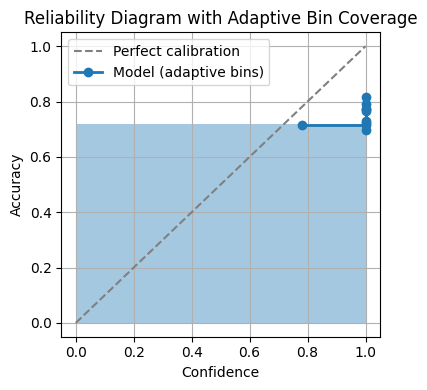

ECE on calibrated answer (test data): 0.2284969538450241
Accuracy on answer from test: 0.7497915029525757


In [ ]:
model = TemperatureCalibration()
model.load_state_dict(fit_results["parameters"])
# model.eval()
    
test_probs = torch.softmax(
    test.get()["scores"],
    dim=-1
).gather(-1, test.get()["tok_ids"].unsqueeze(0)).squeeze(0)       

test_calibrated_probs = torch.softmax(
    model.calibrate(test.get()["scores"]),
    dim=-1
).gather(-1, test.get()["tok_ids"].unsqueeze(0)).squeeze(0)    

test_calibration_model(
    test_probs,
    test_calibrated_probs,
    test.get()["labels"],
)

In [ ]:
model.calibrate(test.get()["scores"])

tensor([[ 4.5614, -9.3128, -9.3128,  ..., -9.3128, -9.3128, -9.3128],
        [ 5.1632, -9.3128, -9.3128,  ..., -9.3128, -9.3128, -9.3128],
        [ 5.0365, -9.3128, -9.3128,  ..., -9.3128, -9.3128, -9.3128],
        ...,
        [ 4.8781, -9.3128, -9.3128,  ..., -9.3128, -9.3128, -9.3128],
        [ 4.6564, -9.3128, -9.3128,  ..., -9.3128, -9.3128, -9.3128],
        [ 4.7514, -9.3128, -9.3128,  ..., -9.3128, -9.3128, -9.3128]],
       device='cuda:3')

In [ ]:
test.get()["scores"]

tensor([[  48.9796, -100.0000, -100.0000,  ..., -100.0000, -100.0000,
         -100.0000],
        [  55.4422, -100.0000, -100.0000,  ..., -100.0000, -100.0000,
         -100.0000],
        [  54.0816, -100.0000, -100.0000,  ..., -100.0000, -100.0000,
         -100.0000],
        ...,
        [  52.3810, -100.0000, -100.0000,  ..., -100.0000, -100.0000,
         -100.0000],
        [  50.0000, -100.0000, -100.0000,  ..., -100.0000, -100.0000,
         -100.0000],
        [  51.0204, -100.0000, -100.0000,  ..., -100.0000, -100.0000,
         -100.0000]], device='cuda:3')

In [ ]:
torch.softmax(
    test.get()["scores"].clamp(-50),
    dim=-1
).gather(1, test.get()["tok_ids"].unsqueeze(0))

tensor([[1., 1., 1.,  ..., 1., 1., 1.]], device='cuda:3')

In [ ]:
torch.softmax(
    model.calibrate(test.get()["scores"].clamp(-50)),
    dim=-1
).gather(1, test.get()["tok_ids"].unsqueeze(0))

tensor([[0.9971, 0.9971, 0.9971,  ..., 0.9971, 0.9971, 0.9971]],
       device='cuda:3')